In [1]:
import pandas as pd

# Load datasets
transaction = pd.read_csv(r"C:\Users\User\BigData\Datasets\train_transaction.csv")
identity = pd.read_csv(r"C:\Users\User\BigData\Datasets\train_identity.csv")

# Merge
df = transaction.merge(identity, on='TransactionID', how='left')

df.shape

(590540, 434)

In [2]:
# Basic data understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [3]:
# Missing value analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64

In [4]:
# Drop useless column
threshold = len(df) * 0.7  # 70% missing

df = df.dropna(thresh=threshold, axis=1)

df.shape

(590540, 202)

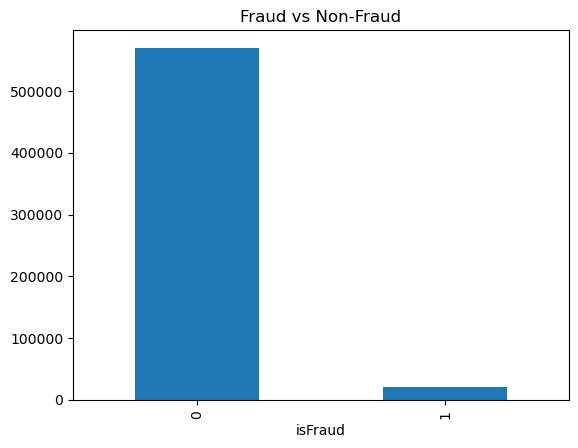

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [5]:
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.show()

df['isFraud'].value_counts(normalize=True)

In [6]:
# correlation
corr = df.corr(numeric_only=True)

# Correlation with target
corr_target = corr['isFraud'].abs().sort_values(ascending=False)

corr_target.head(20)

isFraud    1.000000
V45        0.281832
V44        0.260376
V86        0.251828
V87        0.251737
V52        0.239469
V51        0.223191
V40        0.212442
V39        0.203097
V38        0.199005
V43        0.198274
V79        0.194141
V42        0.189428
V94        0.188407
V74        0.185915
V33        0.183486
V17        0.182673
V18        0.182550
V81        0.182377
V93        0.180983
Name: isFraud, dtype: float64

In [7]:
# Select top features
top_features = corr_target.head(20).index.tolist()

df = df[top_features]

df.shape

(590540, 20)

In [8]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [9]:
df.dtypes

isFraud      int64
V45        float64
V44        float64
V86        float64
V87        float64
V52        float64
V51        float64
V40        float64
V39        float64
V38        float64
V43        float64
V79        float64
V42        float64
V94        float64
V74        float64
V33        float64
V17        float64
V18        float64
V81        float64
V93        float64
dtype: object

In [10]:
# Split Data
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Check NaN count
X_train.isnull().sum().sum()

np.int64(1890919)

In [12]:
# Fix missing value
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [13]:
X_train.isnull().sum().sum()

np.int64(0)

In [14]:
# Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [15]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# Evaluate model
from sklearn.metrics import classification_report

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

print("Logistic Regression:\n", classification_report(y_test, y_pred1))
print("Random Forest:\n", classification_report(y_test, y_pred2))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91    113975
           1       0.09      0.44      0.16      4133

    accuracy                           0.83    118108
   macro avg       0.54      0.64      0.53    118108
weighted avg       0.95      0.83      0.88    118108

Random Forest:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93    113975
           1       0.12      0.43      0.19      4133

    accuracy                           0.87    118108
   macro avg       0.55      0.66      0.56    118108
weighted avg       0.95      0.87      0.91    118108



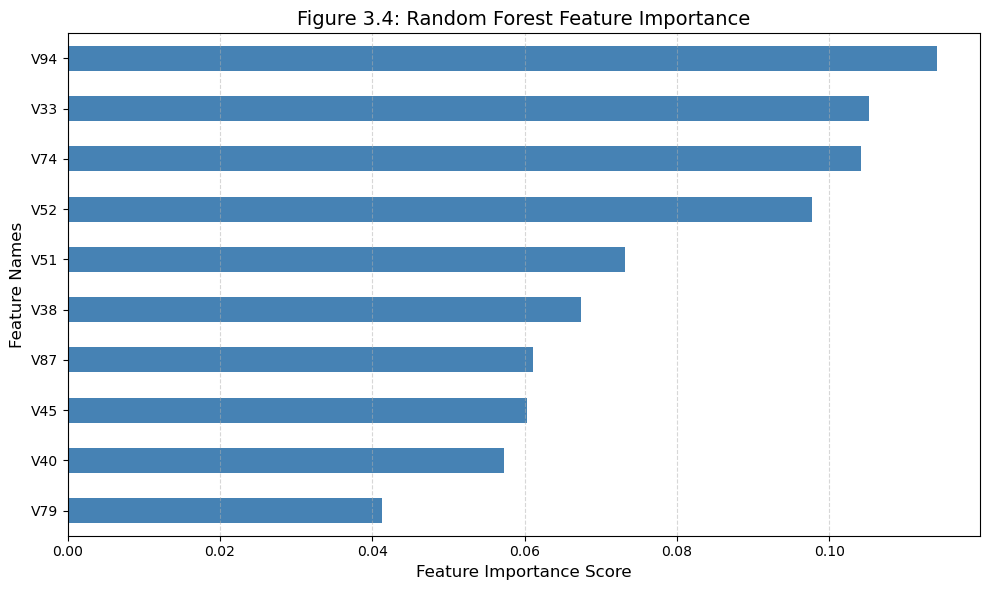

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model2.feature_importances_

feat_importance = pd.Series(
    importance,
    index=X.columns
)

plt.figure(figsize=(10, 6))

feat_importance.sort_values().tail(10).plot(
    kind='barh',
    color='steelblue'
)

plt.title(
    'Figure 3.4: Random Forest Feature Importance',
    fontsize=14
)

plt.xlabel(
    'Feature Importance Score',
    fontsize=12
)

plt.ylabel(
    'Feature Names',
    fontsize=12
)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    'Figure_3_4_RandomForest_FeatureImportance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
# Adjust decision threshold
y_prob = model2.predict_proba(X_test)[:,1]

# Lower threshold
y_pred_adjusted = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.98      0.05      0.09    113975
           1       0.04      0.97      0.07      4133

    accuracy                           0.08    118108
   macro avg       0.51      0.51      0.08    118108
weighted avg       0.94      0.08      0.09    118108



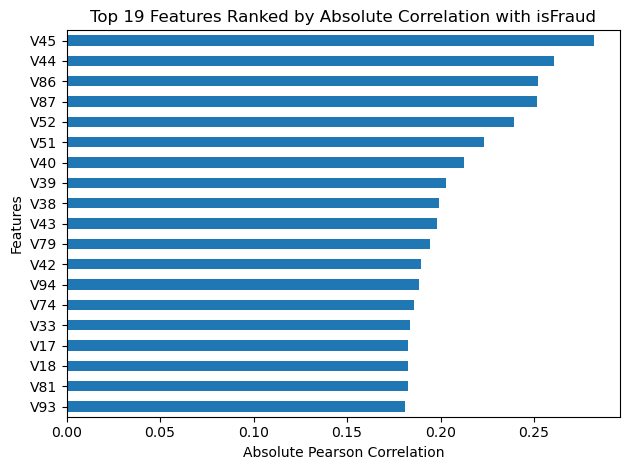

In [20]:
import matplotlib.pyplot as plt

corr_target.drop('isFraud').head(19).sort_values().plot(kind='barh')

plt.title("Top 19 Features Ranked by Absolute Correlation with isFraud")
plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


<Axes: xlabel='isFraud'>

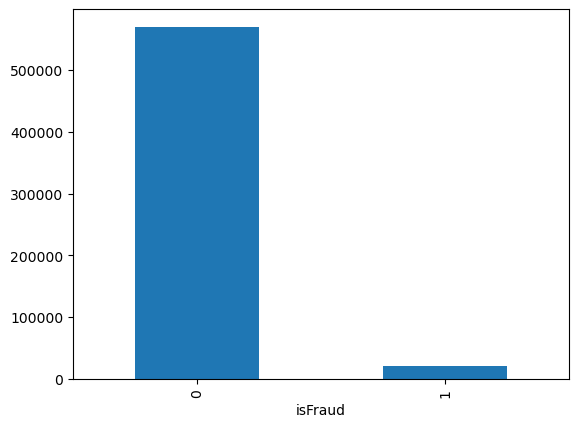

In [21]:
df['isFraud'].value_counts().plot(kind='bar')

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Random Forest probabilities
rf_prob = model2.predict_proba(X_test)[:, 1]

# Logistic Regression probabilities
lr_prob = model1.predict_proba(X_test)[:, 1]

# Random Forest threshold 0.3
y_pred_rf_03 = (rf_prob >= 0.3).astype(int)

performance_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Fraud)",
        "Recall (Fraud)",
        "F1-Score (Fraud)",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred1),
        precision_score(y_test, y_pred1),
        recall_score(y_test, y_pred1),
        f1_score(y_test, y_pred1),
        roc_auc_score(y_test, lr_prob)
    ],
    "Random Forest (Default)": [
        accuracy_score(y_test, y_pred2),
        precision_score(y_test, y_pred2),
        recall_score(y_test, y_pred2),
        f1_score(y_test, y_pred2),
        roc_auc_score(y_test, rf_prob)
    ],
    "Random Forest (Threshold 0.3)": [
        accuracy_score(y_test, y_pred_rf_03),
        precision_score(y_test, y_pred_rf_03),
        recall_score(y_test, y_pred_rf_03),
        f1_score(y_test, y_pred_rf_03),
        "N/A"
    ]
})

performance_table

,Metric,Logistic Regression,Random Forest (Default),Random Forest (Threshold 0.3)
0,Accuracy,0.831502,0.873946,0.081349
1,Precision (Fraud),0.094277,0.123187,0.035589
2,Recall (Fraud),0.443262,0.425357,0.967578
3,F1-Score (Fraud),0.155485,0.191045,0.068654
4,ROC-AUC,0.674769,0.674109,N/A


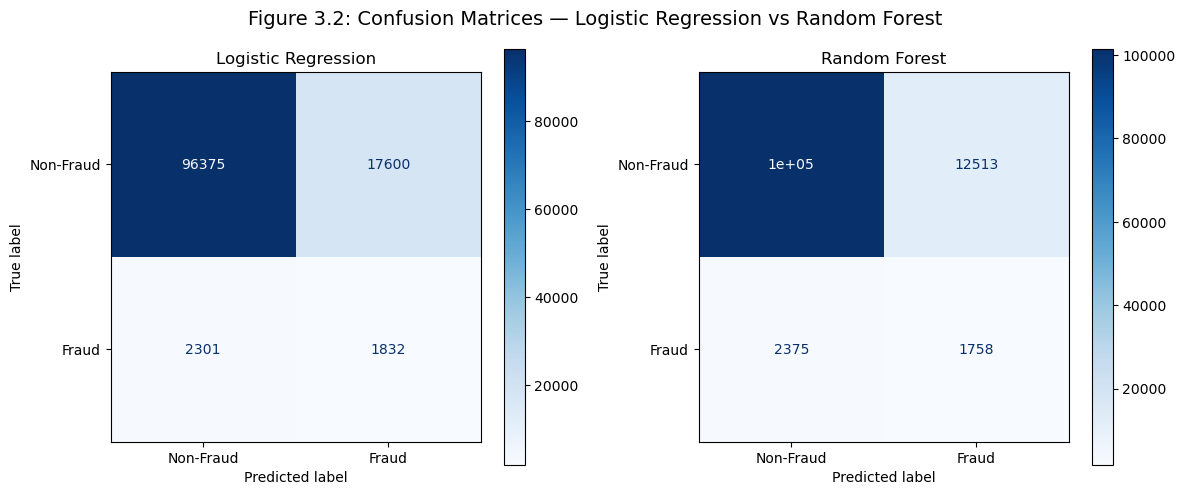

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred1,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Random Forest")

plt.suptitle(
    "Figure 3.2: Confusion Matrices — Logistic Regression vs Random Forest",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure_3_2_Confusion_Matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
rf_prob = model2.predict_proba(X_test)[:, 1]
lr_prob = model1.predict_proba(X_test)[:, 1]

<Figure size 800x600 with 0 Axes>

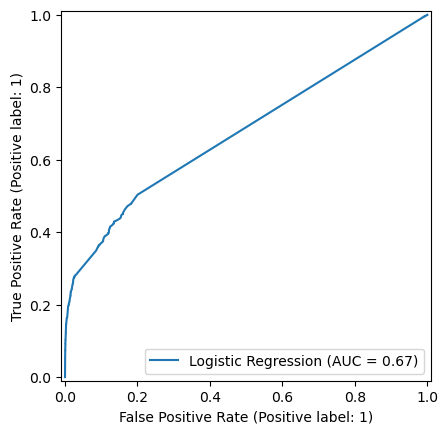

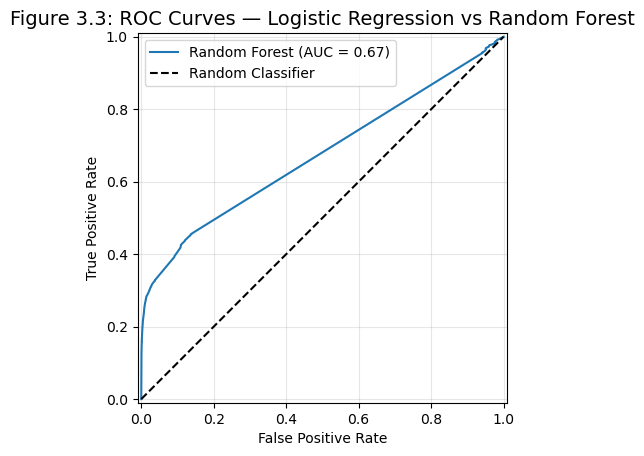

In [26]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.title(
    "Figure 3.3: ROC Curves — Logistic Regression vs Random Forest",
    fontsize=14
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "Figure_3_3_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()